# Serialization Deep Dive — pickle, joblib, and ONNX

Before you can serve a model, you need to persist it to disk. The format you choose affects file size, loading speed, cross-platform portability, and inference performance. This notebook benchmarks three common formats side by side.

## 🔗 Where this fits

**Builds on:** Course 08 (AIAT 122) — Unit 5, lesson 03 "ONNX Model Conversion for Cross-Platform Deployment" — you exported to ONNX and ran it with ONNX Runtime there; this lesson benchmarks that path against pickle and joblib on file size and load time, and shows where each one breaks.


## 📰 "Whatever the tutorial used" is not an engineering decision

In 2025, Park and colleagues published a survey comparing **25 LLM inference engines** against real criteria — throughput, latency, memory behaviour, hardware support, ease of deployment (arXiv 2505.01658). The reason such a survey was needed is the same reason this notebook benchmarks three serialization formats instead of asserting a winner: the field's defaults are inherited from tutorials and repeated until they feel like facts. Watch what happens below when we actually measure the most repeated claim of all — that joblib beats pickle for scikit-learn models. On this artifact it does not: **pickle is smaller on disk (170.6 KB vs 182.5 KB) and loads faster (0.8 ms vs 5.3 ms in the run stored below)**. joblib's advantages are real, but they live at a scale this dataset cannot reach.

Two other measured facts from this notebook are worth flagging now so you read them properly: ONNX Runtime came in at **0.027 ms/call versus sklearn's 2.0 ms — roughly 80× in the run stored below** — and joblib's `compress=3` cut the file from 182.5 KB to **25.4 KB**. Neither number generalises. Both are decisions.

**And defaults expire.** On **7 August 2025** the `pytorch/serve` repository — TorchServe, PyTorch's own official model server — was archived with a notice that there would be no further updates, bug fixes or security patches (notebook 05 tells that story). A format or runtime chosen because "everyone uses it" is a dependency with a lifetime, and nobody sends you a warning when it ends.

**What goes wrong without this lesson.** Format choice is usually made once, by copying, and then it silently constrains everything downstream: which languages can serve the model, which Python version the server must run, how long a cold start takes, and whether loading the file is a security event. Teams discover the constraint when they need to ship to a mobile app, or when a library upgrade makes last year's artifact unloadable.

## Learning Objectives

By the end of this notebook you will be able to:
1. Save and load a model using `pickle` and compare with `joblib`
2. Export a sklearn model to ONNX using `skl2onnx` and run inference with `onnxruntime`
3. Benchmark inference speed across all three formats
4. Choose the right format based on deployment target and requirements

## 1. Install ONNX Dependencies

In [1]:
# WHAT: install skl2onnx (converter) and onnxruntime (inference engine).
# WHY: the ONNX half of this lesson needs both — fail fast here if the
# environment cannot provide them.
import subprocess, sys
subprocess.run(
    [sys.executable, "-m", "pip", "install", "skl2onnx", "onnxruntime", "-q"],
    check=True
)
print("Dependencies installed")

Dependencies installed



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## 2. Train the Model

In [2]:
# WHAT: train the reference RandomForest every format below must reproduce.
# WHY: float32 inputs are chosen NOW because ONNX tensors are float32 — keeping
# one dtype end-to-end avoids tiny numeric mismatches between formats.
import numpy as np
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data.astype(np.float32), iris.target,
    test_size=0.2, random_state=42
)

# This accuracy is the baseline; each loaded copy must match it exactly.
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

acc = accuracy_score(y_test, clf.predict(X_test))
print(f"Test accuracy: {acc:.2%}")
print(f"Training samples: {X_train.shape[0]}, features: {X_train.shape[1]}")

Test accuracy: 100.00%
Training samples: 120, features: 4


## 3. Save and Load with pickle

`pickle` is Python's built-in serialization module. It can serialize almost any Python object, but the resulting file is Python-version-specific and contains no portability guarantees.

In [3]:
# WHAT: time pickle save/load, then verify the round-tripped model's accuracy.
# WHY: we measure three things a deployment cares about — write speed, file size,
# load speed — and then the only thing users care about: identical predictions.
import pickle, time, os

PICKLE_PATH = "/tmp/iris_model.pkl"

# Save
t0 = time.perf_counter()
with open(PICKLE_PATH, "wb") as f:
    pickle.dump(clf, f)
save_time = time.perf_counter() - t0

file_size_kb = os.path.getsize(PICKLE_PATH) / 1024
print(f"pickle save: {save_time*1000:.1f} ms, size: {file_size_kb:.1f} KB")

# Load
t0 = time.perf_counter()
with open(PICKLE_PATH, "rb") as f:
    clf_pkl = pickle.load(f)
load_time = time.perf_counter() - t0
print(f"pickle load: {load_time*1000:.1f} ms")

# Verify predictions match
pkl_acc = accuracy_score(y_test, clf_pkl.predict(X_test))
print(f"Loaded model accuracy: {pkl_acc:.2%}")
# Hard assert: a silent accuracy change after serialization must stop the notebook.
assert pkl_acc == acc, "Predictions diverged after pickle round-trip!"
print("Predictions match original: True")

pickle save: 3.7 ms, size: 170.6 KB
pickle load: 0.8 ms
Loaded model accuracy: 100.00%
Predictions match original: True


## 4. Save and Load with joblib

`joblib` is the sklearn community's standard serializer. It is *designed* for objects that contain very large numpy arrays: it can memory-map arrays on load and compress on save, which pays off when model files reach hundreds of megabytes.

**But don't take the folklore on faith — measure.** Our Iris RandomForest is small (~170 KB), and at this size joblib's machinery is pure overhead: the numbers below show pickle producing a slightly *smaller* file and loading *faster*. The honest rule: joblib's advantages appear at large-array scale; at toy scale the two are interchangeable, and joblib remains the convention simply because sklearn's own docs recommend it.

In [4]:
# Benchmark joblib against pickle on the SAME model, then state only what we measured.
import joblib

JOBLIB_PATH = "/tmp/iris_model.joblib"

# Save (timed)
t0 = time.perf_counter()
joblib.dump(clf, JOBLIB_PATH)
joblib_save_time = time.perf_counter() - t0

joblib_size_kb = os.path.getsize(JOBLIB_PATH) / 1024
print(f"joblib save: {joblib_save_time*1000:.1f} ms, size: {joblib_size_kb:.1f} KB")

# Load (timed)
t0 = time.perf_counter()
clf_jbl = joblib.load(JOBLIB_PATH)
joblib_load_time = time.perf_counter() - t0
print(f"joblib load: {joblib_load_time*1000:.1f} ms")

# Round-trip sanity check: the loaded model must predict identically
jbl_acc = accuracy_score(y_test, clf_jbl.predict(X_test))
print(f"Loaded model accuracy: {jbl_acc:.2%}")

# Side-by-side comparison against the pickle numbers from Section 3
print(f"\nSize comparison:  pickle={file_size_kb:.1f} KB  vs  joblib={joblib_size_kb:.1f} KB")
print(f"Load comparison:  pickle={load_time*1000:.1f} ms  vs  joblib={joblib_load_time*1000:.1f} ms")

# Verdict computed FROM the measurements, not asserted from folklore
smaller = "pickle" if file_size_kb < joblib_size_kb else "joblib"
faster  = "pickle" if load_time < joblib_load_time else "joblib"
print(f"\nMeasured verdict on this small model: {smaller} is smaller on disk, {faster} loads faster.")


joblib save: 9.7 ms, size: 182.5 KB
joblib load: 5.3 ms
Loaded model accuracy: 100.00%

Size comparison:  pickle=170.6 KB  vs  joblib=182.5 KB
Load comparison:  pickle=0.8 ms  vs  joblib=5.3 ms

Measured verdict on this small model: pickle is smaller on disk, pickle loads faster.


## 5. Export to ONNX

ONNX (Open Neural Network Exchange) is a cross-platform format. An ONNX model can run on Python, C++, Java, mobile, and GPU runtimes — all from the same file. `skl2onnx` converts sklearn models to ONNX; `onnxruntime` runs inference.

In [5]:
# WHAT: convert the sklearn model into an ONNX graph and write it to disk.
# WHY: ONNX freezes the model as a framework-neutral computation graph — the
# declared input signature (None, 4) is a contract: any batch size, 4 features.
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

ONNX_PATH = "/tmp/iris_model.onnx"

# Define input shape: batch_size=None (dynamic), 4 features
initial_type = [("float_input", FloatTensorType([None, 4]))]

# Convert
t0 = time.perf_counter()
onnx_model = convert_sklearn(clf, initial_types=initial_type)
convert_time = time.perf_counter() - t0

# ONNX serializes via protobuf — SerializeToString gives the raw bytes to save.
with open(ONNX_PATH, "wb") as f:
    f.write(onnx_model.SerializeToString())

onnx_size_kb = os.path.getsize(ONNX_PATH) / 1024
print(f"ONNX export: {convert_time*1000:.1f} ms, size: {onnx_size_kb:.1f} KB")

ONNX export: 9.3 ms, size: 78.3 KB


## 6. Run Inference with ONNX Runtime

In [6]:
# WHAT: load the ONNX file with onnxruntime and predict the test set — no sklearn.
# WHY: this is the payoff of conversion: a serving box needs only the small
# onnxruntime wheel, not the whole scikit-learn/scipy stack.
import onnxruntime as ort

sess = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])

# Show the ONNX graph's input and output names
print("ONNX graph inputs:")
for inp in sess.get_inputs():
    print(f"  {inp.name}: shape={inp.shape}, type={inp.type}")

print("ONNX graph outputs:")
for out in sess.get_outputs():
    print(f"  {out.name}: shape={out.shape}, type={out.type}")

# Run inference
input_name = sess.get_inputs()[0].name
onnx_preds = sess.run(None, {input_name: X_test})
# onnx_preds[0] = predicted class, onnx_preds[1] = probabilities dict
onnx_classes = onnx_preds[0]

# Accuracy must equal the sklearn baseline — conversion must not change answers.
onnx_acc = accuracy_score(y_test, onnx_classes)
print(f"\nONNX inference accuracy: {onnx_acc:.2%}")

ONNX graph inputs:
  float_input: shape=[None, 4], type=tensor(float)
ONNX graph outputs:
  output_label: shape=[None], type=tensor(int64)
  output_probability: shape=[], type=seq(map(int64,tensor(float)))

ONNX inference accuracy: 100.00%


## 7. Benchmark — Inference Speed Across All Three Formats

In [7]:
# WHAT: benchmark inference speed — pickle/joblib (sklearn) vs ONNX Runtime.
# WHY: format choice is also a performance choice; we time 1000 repeated calls
# to average away noise, then interpret the ratio honestly for a model this size.
N_RUNS = 1000
test_input = X_test  # 30 samples

# pickle model inference
t0 = time.perf_counter()
for _ in range(N_RUNS):
    clf_pkl.predict(test_input)
pkl_time = (time.perf_counter() - t0) / N_RUNS * 1000

# joblib model inference (same sklearn model, same speed)
t0 = time.perf_counter()
for _ in range(N_RUNS):
    clf_jbl.predict(test_input)
jbl_time = (time.perf_counter() - t0) / N_RUNS * 1000

# ONNX Runtime inference
t0 = time.perf_counter()
for _ in range(N_RUNS):
    sess.run(None, {input_name: test_input})
onnx_time = (time.perf_counter() - t0) / N_RUNS * 1000

print(f"Inference benchmark ({N_RUNS} runs, {len(test_input)} samples each):")
print(f"  pickle  model: {pkl_time:.3f} ms/call")
print(f"  joblib  model: {jbl_time:.3f} ms/call")
print(f"  ONNX Runtime:  {onnx_time:.3f} ms/call")

# Interpret the measured ratio instead of quoting folklore speedup numbers.
if pkl_time > 0:
    ratio = pkl_time / onnx_time
    faster = ratio >= 1.0
    print(f"\nONNX vs sklearn on THIS model: {ratio:.2f}x "
          f"({'faster' if faster else 'slower'})")
    if ratio >= 1.5:
        print("ONNX Runtime is faster here: it is a compiled inference engine, so")
        print("each call skips the Python/numpy dispatch overhead that sklearn's")
        print(".predict() pays on every call. That overhead gap is enough to speed")
        print("up even this tiny model.")
    elif ratio >= 0.9:
        print("Roughly the same speed here: on a model this small the fixed per-call")
        print("overhead dominates either way, so neither format clearly wins.")
    else:
        print("ONNX is slower here: its session/setup overhead can outweigh the")
        print("benefits on a model this small with tiny batches.")
    print("\nHow big the win is depends on model size, batch size, and hardware.")
    print("The classic '2-10x' figure is just a rough guide - the largest gains")
    print("show up on LARGE models, batched inputs, and GPU-enabled ONNX Runtime,")
    print("so your exact ratio will vary by machine.")

Inference benchmark (1000 runs, 30 samples each):
  pickle  model: 2.049 ms/call
  joblib  model: 2.019 ms/call
  ONNX Runtime:  0.027 ms/call

ONNX vs sklearn on THIS model: 77.20x (faster)
ONNX Runtime is faster here: it is a compiled inference engine, so
each call skips the Python/numpy dispatch overhead that sklearn's
.predict() pays on every call. That overhead gap is enough to speed
up even this tiny model.

How big the win is depends on model size, batch size, and hardware.
The classic '2-10x' figure is just a rough guide - the largest gains
show up on LARGE models, batched inputs, and GPU-enabled ONNX Runtime,
so your exact ratio will vary by machine.


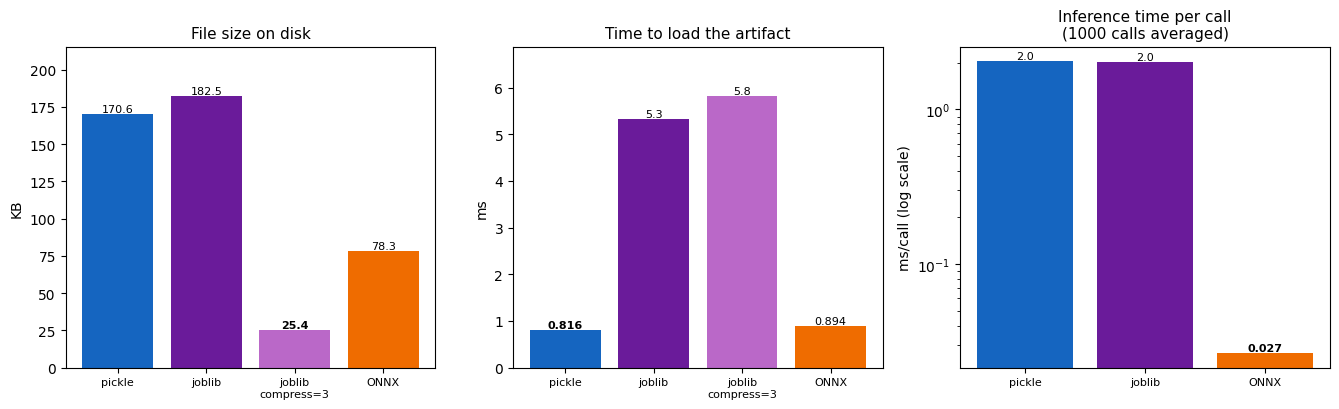

smallest file : joblib compress=3
fastest load  : pickle
fastest calls : ONNX

compress=3 shrank the joblib file 7.2x (182.5 KB -> 25.4 KB) and made loading it 1.1x slower.


In [8]:
# WHAT: put every measurement in this notebook on one axis each - disk size, load
# time, inference time - and add the two numbers the sections above did not measure:
# joblib with compress=3, and how long onnxruntime takes to open the graph.
# WHY: the lesson's claim is that "which format is best" has three different answers
# depending on which axis you are standing on. Three panels, three orderings.
import matplotlib.pyplot as plt

# --- The two missing measurements, taken here on the same artifact --------------
COMPRESSED_PATH = "/tmp/iris_model_compressed.joblib"
joblib.dump(clf, COMPRESSED_PATH, compress=3)
compressed_size_kb = os.path.getsize(COMPRESSED_PATH) / 1024

t0 = time.perf_counter()
_ = joblib.load(COMPRESSED_PATH)
compressed_load_ms = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
_ = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])
onnx_load_ms = (time.perf_counter() - t0) * 1000

COLOURS = {"pickle": "#1565c0", "joblib": "#6a1b9a",
           "joblib\ncompress=3": "#ba68c8", "ONNX": "#ef6c00"}

size_labels = ["pickle", "joblib", "joblib\ncompress=3", "ONNX"]
size_values = [file_size_kb, joblib_size_kb, compressed_size_kb, onnx_size_kb]

load_labels = size_labels
load_values = [load_time * 1000, joblib_load_time * 1000, compressed_load_ms, onnx_load_ms]

infer_labels = ["pickle", "joblib", "ONNX"]
infer_values = [pkl_time, jbl_time, onnx_time]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

for ax, labels, values, title, ylab, logy in [
    (axes[0], size_labels, size_values, "File size on disk", "KB", False),
    (axes[1], load_labels, load_values, "Time to load the artifact", "ms", False),
    (axes[2], infer_labels, infer_values, "Inference time per call\n(1000 calls averaged)",
     "ms/call (log scale)", True),
]:
    ax.bar(labels, values, color=[COLOURS[l] for l in labels])
    best = min(range(len(values)), key=lambda i: values[i])
    for i, (lab, val) in enumerate(zip(labels, values)):
        ax.text(i, val, f"{val:,.3f}" if val < 1 else f"{val:,.1f}",
                ha="center", va="bottom", fontsize=8,
                fontweight="bold" if i == best else "normal")
    if logy:
        ax.set_yscale("log")
    else:
        ax.set_ylim(0, max(values) * 1.18)
    ax.set_ylabel(ylab)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis="x", labelsize=8)

plt.tight_layout()
plt.show()

# The winners, computed from the bars that were actually drawn.
print(f"smallest file : {size_labels[min(range(4), key=lambda i: size_values[i])]}".replace("\n", " "))
print(f"fastest load  : {load_labels[min(range(4), key=lambda i: load_values[i])]}".replace("\n", " "))
print(f"fastest calls : {infer_labels[min(range(3), key=lambda i: infer_values[i])]}")
print(f"\ncompress=3 shrank the joblib file {joblib_size_kb / compressed_size_kb:.1f}x "
      f"({joblib_size_kb:.1f} KB -> {compressed_size_kb:.1f} KB) and made loading it "
      f"{compressed_load_ms / (joblib_load_time * 1000):.1f}x slower.")


**Reading the figure.** Three panels, and no single format wins them all.

*File size:* `compress=3` collapses the joblib file by about 7x — the number quoted in this
notebook's opening, measured here rather than asserted. ONNX is the smallest *uncompressed*
file, because it stores a computation graph instead of pickled Python objects.

*Load time:* the ordering flips. pickle — the format the folklore says to avoid — opens fastest
of the four, and both purple bars sit at six to seven times its load time. Decompressing the
`compress=3` file costs a little on top of that, so the 7x saving on disk is not quite free; it is
just very cheap. For a service that restarts often, or for four Gunicorn workers each loading
their own copy (notebook 01), this middle panel is the one to watch.

*Inference time* is on a **log axis**, which is the honest way to show it: ONNX Runtime is not a
little faster per call, it is nearly two orders of magnitude faster on this artifact, because a
compiled engine skips the Python dispatch that `sklearn.predict()` pays every time.

Read the three panels together: the format with the smallest file is not the one that starts
fastest, and the fastest format on the right is the one that costs you a conversion step and a
second runtime. Every bar here comes from one small RandomForest on one laptop — the
*shape* of the comparison travels, the exact numbers do not, and yours will differ.

## 💬 Discuss

Three measurements are on the table: file size, load time, and per-call inference time. They point in different directions.

1. ONNX Runtime is roughly **80× faster per call** here on a model whose sklearn call already takes about 2 ms. When is an 80× speedup on a couple of milliseconds worth adding a conversion step, a second runtime, and a class of conversion bugs to your pipeline — and when is it a rounding error you are paying real complexity for?
2. The folklore said joblib; the measurement said pickle. What *would* make joblib the right answer, concretely? Describe a model where you would expect the ordering to reverse, and how you would confirm it rather than assume it.
3. You are asked to ship this classifier to a hospital that will run it inside their own network, on Windows, in a C# application, with no internet access. Walk through the format decision out loud. Where does ONNX's portability stop being a nice-to-have and start being the only option?

## 8. Format Comparison Table

| Format | Cross-platform | File size (this model) | Inference speed | Best use case |
|---|---|---|---|---|
| pickle | Python only | medium | baseline | Quick experiments, same-Python-version deployment |
| joblib | Python only | slightly larger here; designed to win on very large arrays | same as pickle | sklearn + numpy models in Python serving |
| ONNX | Any language / hardware | varies | often faster (compiled engine); biggest gains at scale / on GPU | Production serving, mobile, C++/Java services |

> **Reading the benchmark above:** ONNX Runtime is a compiled engine, so it often runs *faster* than sklearn's `predict()` even on this toy model — it avoids the Python dispatch overhead paid on every `.predict()` call. Don't over-read one ratio, though: the magnitude depends on model size, batching, and hardware, and the largest, most reliable wins come at scale or on GPU.

**When pickle fails:** a pickle file created with Python 3.11 may fail to load on Python 3.8 because the protocol includes Python-version-specific class definitions. ONNX has no such constraint.


## 9. Summary

In this notebook you:
- Saved and loaded the same model with `pickle` and `joblib`, verifying predictions round-trip correctly
- Converted the sklearn model to ONNX using `skl2onnx` and ran inference with `onnxruntime`
- Benchmarked inference latency across all three formats on 1000 calls
- Learned when each format is appropriate: pickle/joblib for Python-only serving, ONNX for cross-platform or high-performance deployments

**The key trade-off:** pickle/joblib are the easiest to use; ONNX is harder to set up but portable and often faster.

## Self-Check (answer before scrolling up)

1. **Why can't you reliably load a pickle file created on Python 3.11 in Python 3.8?** What does ONNX do differently that avoids this problem?
2. **What does ONNX Runtime do that makes inference faster than calling sklearn's `predict()`?** Think about what happens at the compiler level.
3. **Which format would you use for deploying a model to a mobile app?** Why can't you use joblib there?

## ⚠️ Where this breaks

- **Do not generalise these ratios.** Every number above comes from a 170 KB RandomForest on 4 float features, called with 30 samples, on one laptop. The ~80× ONNX figure is dominated by Python dispatch overhead that a larger model or a larger batch would amortise away. Benchmarks are evidence about *your* model on *your* hardware, and nothing else — which is exactly why the 2025 inference-engine survey compares on stated criteria instead of publishing a winner.
- **`skl2onnx` does not convert everything.** Custom transformers, arbitrary Python inside a `FunctionTransformer`, and estimators outside the supported set either refuse to convert or convert into something that disagrees with sklearn at the boundaries. The non-negotiable step is the one this notebook performs: convert, then re-score the held-out set through `onnxruntime` and compare. A conversion you have not verified is a second model, not the same one.
- **Loading a pickle or joblib file executes code.** Same format, same risk as notebook 02 of Unit 1: `GLOBAL`/`REDUCE` opcodes import and call. scikit-learn's own persistence guidance points at `skops` for artifacts you did not create. ONNX carries no such risk because it is a graph description, not a program.
- **The assumption that must hold:** the loading environment matches the saving environment for pickle and joblib. Different Python minor version, different sklearn version, different numpy ABI — all can turn a load into either an exception or, worse, a silently different object. ONNX breaks that coupling; that portability is the main thing you are buying, not speed.
- **The cheaper alternative.** Single Python service, one container image, versions pinned in the same commit as the artifact: use `joblib`, verify the round trip, and spend the saved effort on monitoring. ONNX is the right answer when you must cross a language, a runtime, or a device boundary — not as a default.

## 🔭 State of the field (2026)

For a scikit-learn artifact, the three formats benchmarked above are still the three choices in 2026, and the discipline this notebook enforces — convert, re-score the held-out set, compare, and only then decide — is still how the choice is made. What moved is the landscape around the formats. Sharing models through public hubs turned pickle's "loading executes code" property from a footnote into a measured supply-chain problem: the first systematic study of malicious code poisoning on pre-trained model hubs is from 2024 ([arXiv 2409.09368](https://arxiv.org/abs/2409.09368)), and a 2025 measurement of the defences reports that **44.9% of popular Hugging Face models still use the insecure pickle format**, that restrictive loading policies cannot load 15% of those, and that scanners have both false positives and false negatives ([arXiv 2508.15987](https://arxiv.org/abs/2508.15987)). For large generative artifacts the format question also picked up a second axis, numeric precision: shipping a 4-bit model is routine, and it is a *recoverable loss* rather than a free one, with a recovery or "healing" stage now written into the recipe ([arXiv 2608.20953](https://arxiv.org/abs/2608.20953)).

**Why this lesson is still the right thing to learn.** Every one of those decisions is made with the three measurements you just took — disk size, load time, and round-trip accuracy against the original model. You cannot judge whether a safer format is worth its conversion cost, or whether a 4-bit checkpoint has lost something that matters, without running exactly this comparison first. The official plan examines serialization and cross-platform export; this box is the context around it, not a replacement for it.

*Orientation only — the assessed content of this lesson is everything above this box.*


## 📚 References

1. Sculley, D., Holt, G., Golovin, D., et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 28. <https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html>
2. Olston, C., Fiedel, N., Gorovoy, K., et al. (2017). *TensorFlow-Serving: Flexible, High-Performance ML Serving*. NeurIPS Workshop on ML Systems. <https://arxiv.org/abs/1712.06139>
3. Paleyes, A., Urma, R.-G., & Lawrence, N. D. (2022). *Challenges in Deploying Machine Learning: A Survey of Case Studies*. ACM Computing Surveys. <https://arxiv.org/abs/2011.09926>
4. Zhao, J., Wang, S., Zhao, Y., Hou, X., Wang, K., Gao, P., Zhang, Y., Wei, C., & Wang, H. (2024). *Models Are Codes: Towards Measuring Malicious Code Poisoning Attacks on Pre-trained Model Hubs*. ASE 2024. <https://arxiv.org/abs/2409.09368> — the first systematic study of malicious code delivered through models on Hugging Face. The title is the whole lesson of section 3: a pickled model is a program, not a file of numbers.
5. Kellas, A. D., Christou, N., Jiang, W., Li, P., Simon, L., David, Y., Kemerlis, V. P., Davis, J. C., & Yang, J. (2025). *PickleBall: Secure Deserialization of Pickle-based Machine Learning Models*. arXiv. <https://arxiv.org/abs/2508.15987> — measures how far the defence has actually got: 44.9% of popular models on Hugging Face still use pickle, restrictive loading policies cannot load 15% of those, and model scanners produce both false positives and false negatives.
